# 04: Baseline Models

## 1. Imports

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    MODEL_DATA_DIR,
    RESULTS_DIR,
    TARGET,
)

## 2. Load Datasets

In [2]:
train = pd.read_csv(
    MODEL_DATA_DIR / "dummy_classifier_train.csv"
)

test = pd.read_csv(
    MODEL_DATA_DIR / "dummy_classifier_test.csv"
)

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Training rows:", len(train))
print("Test rows:", len(test))
print("Training attrition rate:", f"{y_train.mean():.1%}")
print("Test attrition rate:", f"{y_test.mean():.1%}")

Training rows: 846
Test rows: 212
Training attrition rate: 16.9%
Test attrition rate: 17.0%


## 3. Majority-Class Accuracy

In [3]:
majority_class = y_train.mode()[0]

majority_accuracy = (
    y_test == majority_class
).mean()

print("Majority class:", majority_class)
print("Majority-class accuracy:", f"{majority_accuracy:.1%}")

Majority class: 0
Majority-class accuracy: 83.0%


## Train the Models

In [4]:
dummy_models = {
    "Dummy - Most Frequent": DummyClassifier(
        strategy="most_frequent",
        random_state=42,
    ),
    "Dummy - Prior": DummyClassifier(
        strategy="prior",
        random_state=42,
    ),
}

results = []
predictions = []

for model_name, model in dummy_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "brier_score": brier_score_loss(y_test, y_prob),
    })

    predictions.append(pd.DataFrame({
        "model": model_name,
        "actual": y_test.values,
        "prediction": y_pred,
        "probability": y_prob,
    }))

baseline_results = pd.DataFrame(results)

baseline_results

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Dummy - Most Frequent,0.830189,0.5,0.0,0.0,0.0,0.5,0.169811,0.169811
1,Dummy - Prior,0.830189,0.5,0.0,0.0,0.0,0.5,0.169811,0.140976


## 5. Compare the baseline metrics

In [5]:
display_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "brier_score",
]

baseline_results[display_columns].round(3)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Dummy - Most Frequent,0.83,0.5,0.0,0.0,0.0,0.5,0.17,0.170
1,Dummy - Prior,0.83,0.5,0.0,0.0,0.0,0.5,0.17,0.141


## 6. Confusion matrices

In [6]:
for model_name, model in dummy_models.items():
    y_pred = model.predict(X_test)

    matrix = confusion_matrix(y_test, y_pred)

    print(model_name)
    print(matrix)
    print()

Dummy - Most Frequent
[[176   0]
 [ 36   0]]

Dummy - Prior
[[176   0]
 [ 36   0]]



## 7. Confusion Matrix Plots

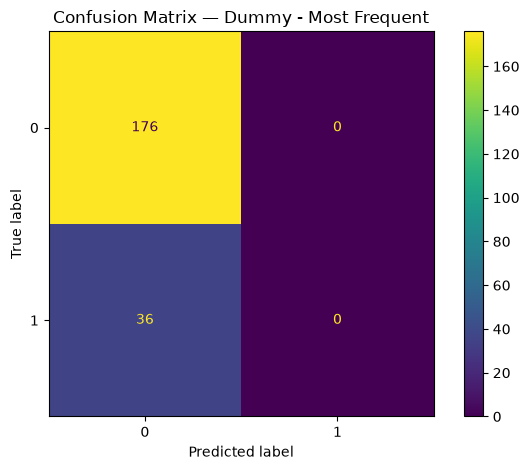

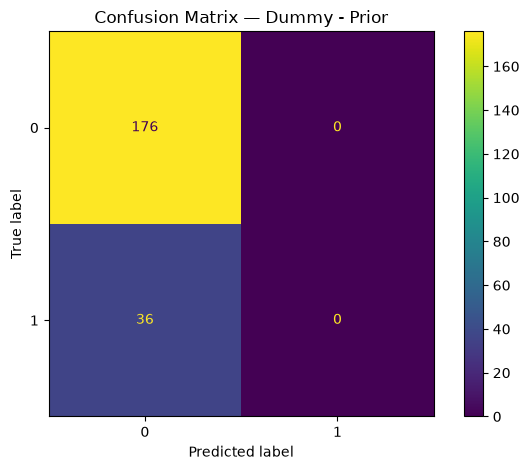

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, model in dummy_models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

## 8. ROC curves

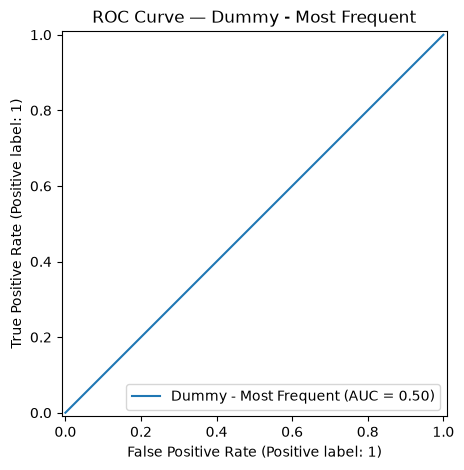

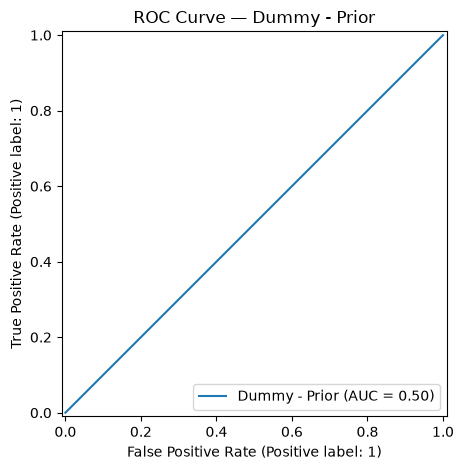

In [8]:
from sklearn.metrics import RocCurveDisplay

for model_name, model in dummy_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
    )

    plt.title(f"ROC Curve — {model_name}")
    plt.tight_layout()
    plt.show()


## 9. Precision–Recall curves

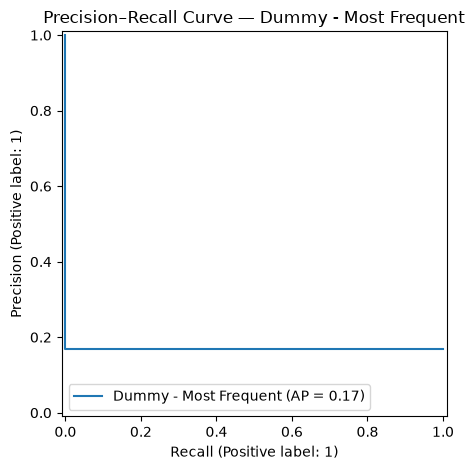

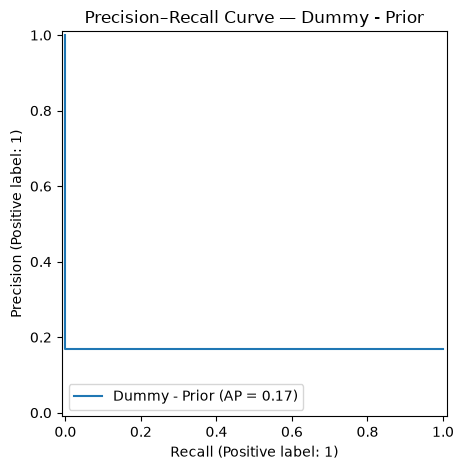

In [9]:
from sklearn.metrics import PrecisionRecallDisplay

for model_name, model in dummy_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
    )

    plt.title(f"Precision–Recall Curve — {model_name}")
    plt.tight_layout()
    plt.show()

## 10. Probability Distributions

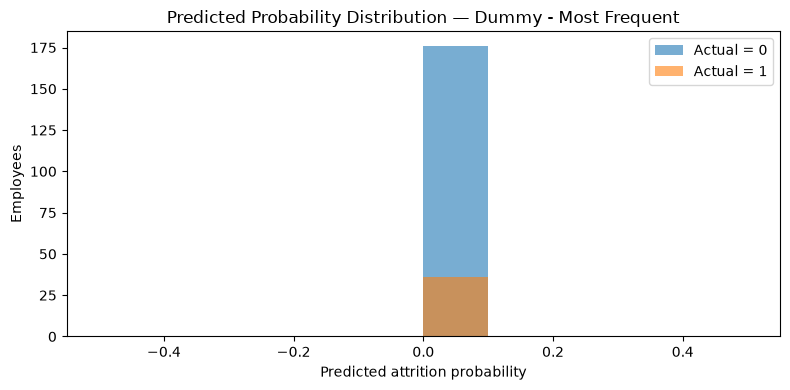

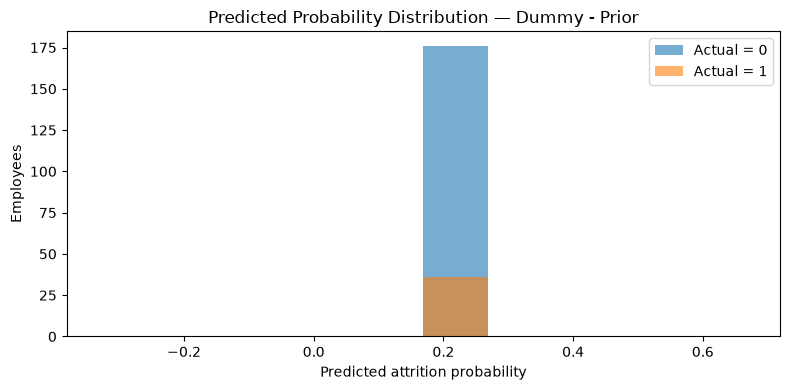

In [10]:
for model_name, model in dummy_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    probability_frame = pd.DataFrame({
        "Actual": y_test.values,
        "Probability": y_prob,
    })

    plt.figure(figsize=(8, 4))

    for actual_value in sorted(probability_frame["Actual"].unique()):
        values = probability_frame.loc[
            probability_frame["Actual"] == actual_value,
            "Probability",
        ]

        plt.hist(
            values,
            bins=10,
            alpha=0.6,
            label=f"Actual = {actual_value}",
        )

    plt.title(f"Predicted Probability Distribution — {model_name}")
    plt.xlabel("Predicted attrition probability")
    plt.ylabel("Employees")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. Calibration Curves

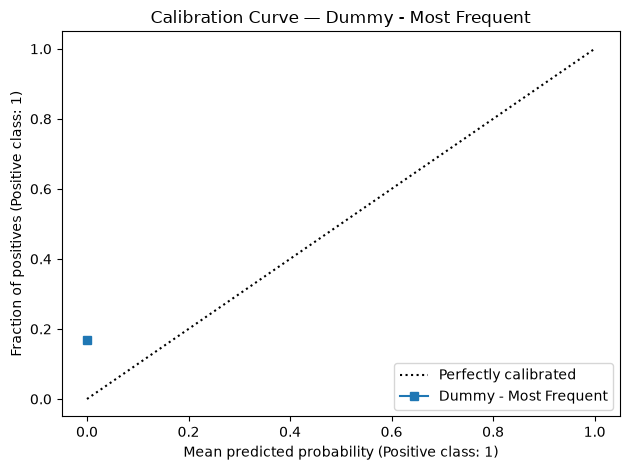

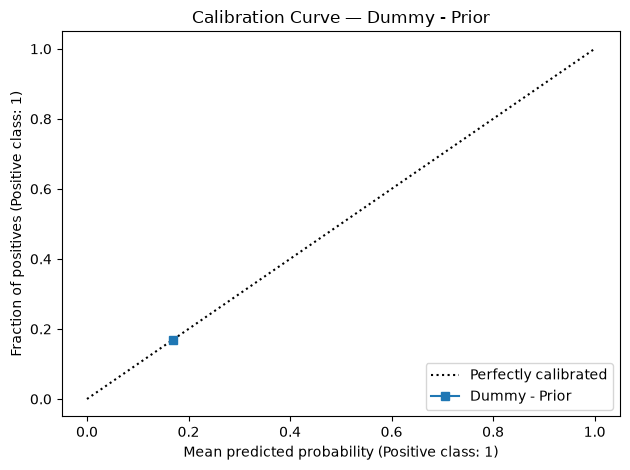

In [11]:
from sklearn.calibration import CalibrationDisplay

for model_name, model in dummy_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    CalibrationDisplay.from_predictions(
        y_test,
        y_prob,
        n_bins=5,
        name=model_name,
        strategy="uniform",
    )

    plt.title(f"Calibration Curve — {model_name}")
    plt.tight_layout()
    plt.show()

## 12. Baseline Metric Comparison

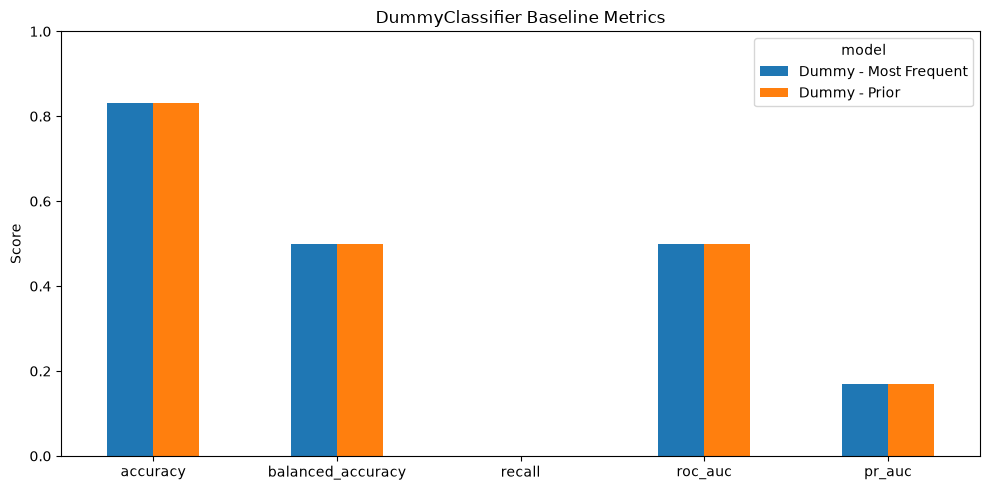

In [12]:
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "recall",
    "roc_auc",
    "pr_auc",
]

plot_data = (
    baseline_results
    .set_index("model")[metrics_to_plot]
    .T
)

plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("DummyClassifier Baseline Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Save the Results

In [13]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False,
)

baseline_predictions = pd.concat(
    predictions,
    ignore_index=True,
)

baseline_predictions.to_csv(
    RESULTS_DIR / "baseline_holdout_predictions.csv",
    index=False,
)

print("Saved baseline results to:", RESULTS_DIR)

Saved baseline results to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
